---
downloads:
  - url: https://colab.research.google.com/github/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard/blob/main/LS100_02_Data-Science_Stats/LS100_Data-wrangling_helpercode_Finding-local-extremum-in-data.ipynb
    title: Open in Colab
  - url: https://codespaces.new/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard?devcontainer_path=.devcontainer%2Fdevcontainer.json
    title: Open in GitHub Codespaces
  - file: LS100_Data-wrangling_helpercode_Finding-local-extremum-in-data.ipynb
    title: Download notebook
---


# Trimming Files Using Local Extremum:

*Authored by* **Souvik Mandal, Ph.D.**

*Project Leader & Instructor, Computational Behavioral Sciences, LS100, FAS, Harvard University* | Linkedin ID: [souvik-mandal-phd](https://www.linkedin.com/in/souvik-mandal-phd/)

---



_Last updated: 2026-07-02_ <!--last-updated-->


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

### 1. Data Exploration: Counting total number of frames in each file

In [26]:
csv_dir = Path("/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/Henry/Henrys-Compile-Angles-Outputs/")

row_counts = {}

for csv_path in sorted(csv_dir.glob("*.csv")):
    df = pd.read_csv(csv_path)
    row_counts[csv_path.name] = len(df)

row_counts_df = pd.DataFrame.from_dict(row_counts, orient="index", columns=["row_count"])
row_counts_df.index.name = "file_name"
row_counts_df

,row_count
file_name,
LS100_FInalData_10_final_kinematics_healed_id__angles_training_sheet.csv,618
LS100_FInalData_11_final_kinematics_healed_id__angles_training_sheet.csv,333
LS100_FInalData_12_final_kinematics_healed_id__angles_training_sheet.csv,369
LS100_FInalData_13_final_kinematics_healed_id__angles_training_sheet.csv,350
LS100_FInalData_14_final_kinematics_healed_id__angles_training_sheet.csv,334
LS100_FInalData_15_final_kinematics_healed_id__angles_training_sheet.csv,409
LS100_FInalData_16_final_kinematics_healed_id__angles_training_sheet.csv,478
LS100_FInalData_17_final_kinematics_healed_id__angles_training_sheet.csv,1170
LS100_FInalData_18_final_kinematics_healed_id__angles_training_sheet.csv,448


## 2. Detecting the "inflection point" for each angle

### 2.1. Data Exploration with one file:

In [19]:
test_df = pd.read_csv("/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/Henry/Henrys-Compile-Angles-Outputs/LS100_FinalData_29_final_kinematics_healed_id__angles_training_sheet.csv")

test_df.head()

,frame,time_ms,h1_elbow,h1_hip,h1_knee,h2_elbow,h2_hip,h2_knee,h1_right_of_way,h2_right_of_way
0,0.0,0.000000,120.120345,127.630992,143.675237,96.292163,146.432061,127.888548,0.0,1.0
1,1.0,33.333333,120.258035,127.688691,143.571725,96.077673,146.471623,127.935087,0.0,1.0
2,2.0,66.666667,120.214963,127.752498,143.436256,95.909207,146.586505,128.002764,0.0,1.0
3,3.0,100.000000,120.162399,127.791365,143.334332,96.040319,146.668893,128.209774,0.0,1.0
4,4.0,133.333333,120.052000,127.789179,143.169513,96.150371,146.955154,128.421602,0.0,1.0


In [20]:
test_df.shape

(291, 10)

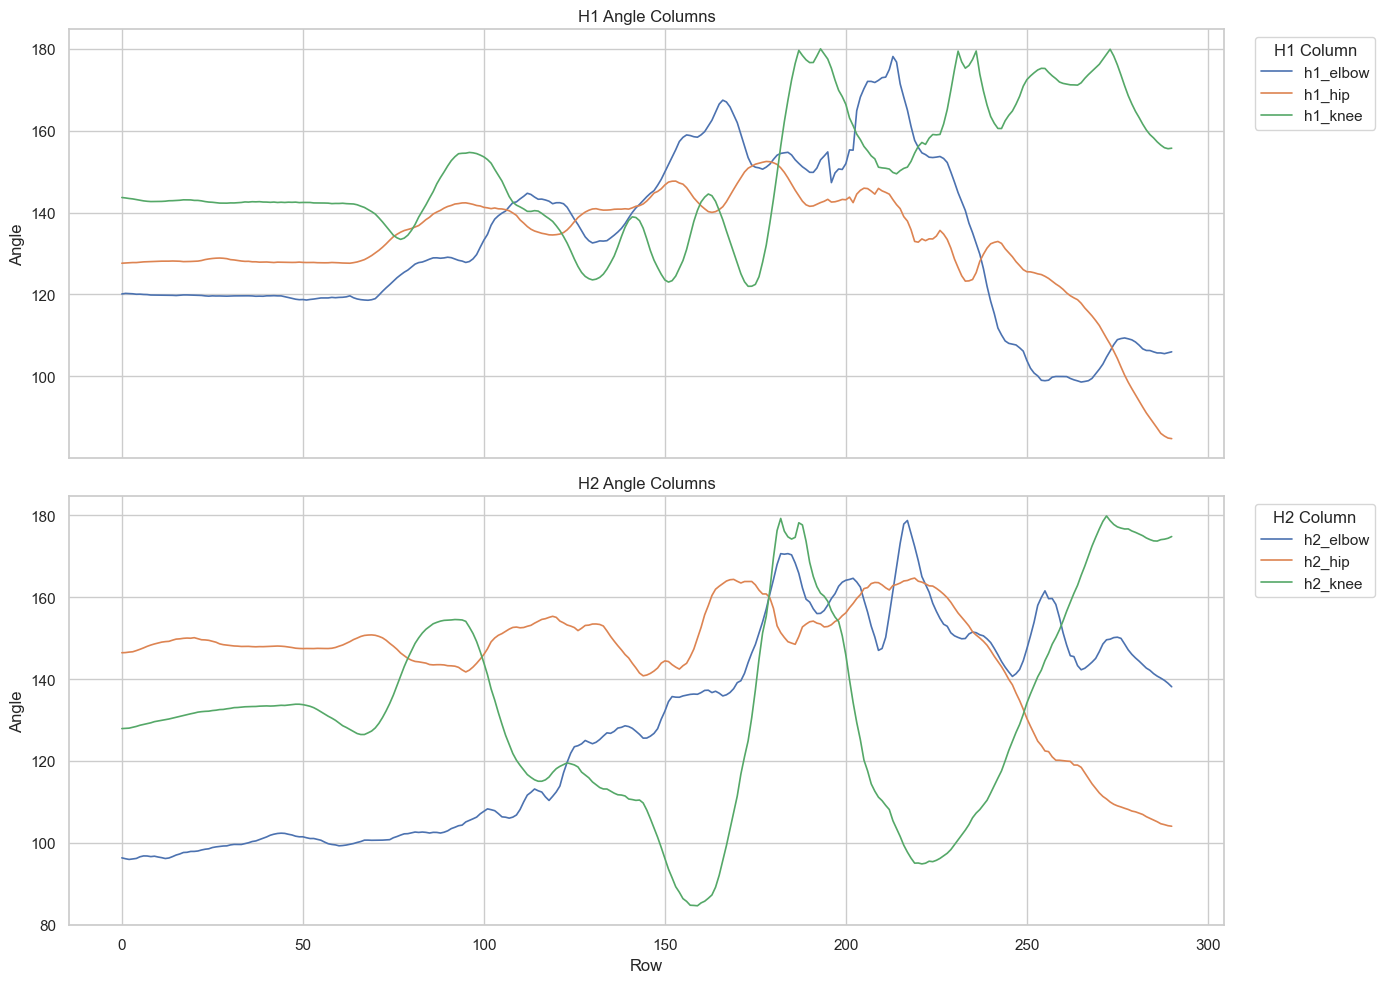

In [24]:
h1_cols = ["h1_elbow", "h1_hip", "h1_knee"]
h2_cols = ["h2_elbow", "h2_hip", "h2_knee"]

available_h1_cols = [col for col in h1_cols if col in test_df.columns]
available_h2_cols = [col for col in h2_cols if col in test_df.columns]

if not available_h1_cols and not available_h2_cols:
    raise ValueError("None of the requested angle columns were found in test_df.")

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for col in available_h1_cols:
    sns.lineplot(
        x=test_df.index,
        y=test_df[col],
        ax=axes[0],
        label=col,
        linewidth=1.2,
    )

for col in available_h2_cols:
    sns.lineplot(
        x=test_df.index,
        y=test_df[col],
        ax=axes[1],
        label=col,
        linewidth=1.2,
    )

axes[0].set_title("H1 Angle Columns")
axes[0].set_ylabel("Angle")
if available_h1_cols:
    axes[0].legend(title="H1 Column", bbox_to_anchor=(1.02, 1), loc="upper left")
else:
    axes[0].text(0.5, 0.5, "No h1 columns found", ha="center", va="center", transform=axes[0].transAxes)

axes[1].set_title("H2 Angle Columns")
axes[1].set_xlabel("Row")
axes[1].set_ylabel("Angle")
if available_h2_cols:
    axes[1].legend(title="H2 Column", bbox_to_anchor=(1.02, 1), loc="upper left")
else:
    axes[1].text(0.5, 0.5, "No h2 columns found", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

### 3. Finding the Last "Inflection Point" - the local extremum.
### 3.1. Goal and working definition for the local extremum search on one file

Our goal is to find, for each angle column, the last meaningful **turning point** near the end of the movement.

In this notebook, we are **not** using the strict calculus idea of an inflection point. Instead, we are looking for a **local extremum**: a peak or a valley where the direction of motion changes. In practical terms, this is a point where the **first derivative changes sign** after smoothing.

**Working definition**

For each angle series, we will search only within the last part of the movement and identify the last stable turning point. A turning point is where the smoothed slope changes state, for example:

- upward to downward
- upward to flat
- downward to upward
- downward to flat
- flat to upward
- flat to downward

**Search region**

Instead of hard-coding a fixed number of frames, we will define the search window from the size of the file itself.

If a file has `n` total frames, then the turning-point search will be restricted to the last `n / 4` frames. This makes the method scale naturally for shorter and longer files.

**Process we will use**

1. Take one angle column at a time.
2. Restrict the search to the last `n / 4` frames.
3. Smooth the signal with a **Savitzky-Golay filter** so small frame-to-frame noise does not create false direction changes.
4. Compute the **first derivative** of the smoothed signal. This derivative represents the slope of the line at each frame.
5. Classify each slope as `up`, `down`, or `flat` using a threshold.
6. Scan backward from the end and return the row index of the last clear state change.
7. If no clear change is found in that tail region, return `None`.

**How we will define the threshold**

The threshold will be derived from the **last slope value after smoothing**. The idea is to compare earlier slopes against the movement trend at the end of the action.

Because the final slope may sometimes be very small, we will likely pair this rule with a small minimum floor so that tiny fluctuations are not treated as meaningful direction changes.

This gives us a rule that is easy to explain to students:

- smooth the signal first
- estimate the slope near the end of the motion
- use that end-of-motion slope to decide what counts as `up`, `down`, or `flat`

**Outputs we want**

We want two levels of output for each file:

1. A separate row index for each of the 6 angle columns.
2. One combined **global event frame** for the file as a whole.

**Working definition for the global event frame**

A practical first approach is to calculate the turning point for each column separately, keep only the valid row indices, and then combine them into one global event frame using the **median** of the detected row indices.

The median is a good starting choice because it is less sensitive to one unusual column than the mean. If too few columns produce a valid turning point, then the global event frame can also be set to `None`.

So the final result for one file will be:

- 6 individual turning-point row indices, one per angle column
- 1 global event frame based on the combined information from those columns

In [27]:
import numpy as np
from scipy.signal import savgol_filter


def _choose_window_length(n_points: int, preferred: int = 11, polyorder: int = 3) -> int | None:
    max_window = n_points if n_points % 2 == 1 else n_points - 1
    min_window = polyorder + 2
    if min_window % 2 == 0:
        min_window += 1

    preferred = preferred if preferred % 2 == 1 else preferred - 1
    window_length = min(preferred, max_window)

    if window_length < min_window:
        window_length = min_window

    if window_length > max_window or window_length <= polyorder:
        return None

    return window_length


def _classify_slope(slope_value: float, threshold: float) -> int:
    if slope_value > threshold:
        return 1
    if slope_value < -threshold:
        return -1
    return 0


def _stable_state(window: np.ndarray) -> int | None:
    unique_values = np.unique(window)
    if len(unique_values) == 1:
        return int(unique_values[0])
    return None


def find_turning_point_from_end(
    series: pd.Series,
    tail_fraction: float = 0.25,
    preferred_window: int = 11,
    polyorder: int = 3,
    slope_threshold_ratio: float = 0.5,
    min_slope_threshold: float = 0.25,
    min_state_run: int = 3,
) -> int | None:
    numeric_series = pd.to_numeric(series, errors="coerce")
    n_points = len(numeric_series)
    if n_points == 0:
        return None

    tail_size = max(1, int(np.ceil(n_points * tail_fraction)))
    tail_start = n_points - tail_size
    tail_series = numeric_series.iloc[tail_start:].copy()

    if tail_series.dropna().shape[0] < polyorder + 2:
        return None

    tail_series = tail_series.interpolate(limit_direction="both")
    if tail_series.isna().any():
        return None

    window_length = _choose_window_length(len(tail_series), preferred=preferred_window, polyorder=polyorder)
    if window_length is None:
        return None

    smoothed = savgol_filter(
        tail_series.to_numpy(),
        window_length=window_length,
        polyorder=polyorder,
        mode="interp",
    )
    slope = np.gradient(smoothed)

    last_slope = float(slope[-1])
    threshold = max(abs(last_slope) * slope_threshold_ratio, min_slope_threshold)
    states = np.array([_classify_slope(value, threshold) for value in slope], dtype=int)

    if len(states) < (2 * min_state_run + 1):
        return None

    for boundary in range(len(states) - min_state_run - 1, min_state_run - 1, -1):
        left_state = _stable_state(states[boundary - min_state_run + 1 : boundary + 1])
        right_state = _stable_state(states[boundary + 1 : boundary + 1 + min_state_run])

        if left_state is None or right_state is None:
            continue
        if left_state == right_state:
            continue
        if left_state == 0 and right_state == 0:
            continue

        search_start = max(0, boundary - min_state_run + 1)
        search_end = min(len(slope) - 1, boundary + min_state_run)
        candidate_offset = int(np.argmin(np.abs(slope[search_start : search_end + 1])))
        candidate_position = search_start + candidate_offset
        return tail_start + candidate_position

    return None


def detect_turning_points_for_file(
    df: pd.DataFrame,
    cols: list[str] | None = None,
    min_valid_events: int = 3,
    **detector_kwargs,
) -> pd.Series:
    if cols is None:
        cols = ["h1_elbow", "h1_hip", "h1_knee", "h2_elbow", "h2_hip", "h2_knee"]

    results = {}
    for col in cols:
        if col in df.columns:
            results[col] = find_turning_point_from_end(df[col], **detector_kwargs)
        else:
            results[col] = None

    valid_rows = [row_id for row_id in results.values() if row_id is not None]
    results["global_event_frame"] = (
        int(np.rint(np.median(valid_rows))) if len(valid_rows) >= min_valid_events else None
    )

    return pd.Series(results, name="row_id")


angle_columns = ["h1_elbow", "h1_hip", "h1_knee", "h2_elbow", "h2_hip", "h2_knee"]
turning_point_results = detect_turning_points_for_file(test_df, cols=angle_columns)
turning_point_results

h1_elbow              287
h1_hip                234
h1_knee               272
h2_elbow              256
h2_hip                261
h2_knee               286
global_event_frame    266
Name: row_id, dtype: int64

### 3.2. Trimming the files properly using the global event frame

Our next goal is to create a new trimmed version of each file using the detected `global_event_frame` as the reference point.

The final output file should always contain **240 frames**. To do that, we will first align the file around the global event frame and then adjust the file length according to a simple set of rules.

**Goal**

For each input file, we want to create a new output dataframe that:

- keeps the movement up to the detected `global_event_frame`
- removes frames that occur after that event frame
- ends with exactly **240 rows** in the saved output file

The output filename will be the same as the input filename, but with `_trimed` inserted before the `.csv` extension.

For example:

- input: `example.csv`
- output: `example_trimed.csv`

**Step-by-step trimming logic**

1. Start with the original input file.
2. Find the `global_event_frame` for that file.
3. Remove every frame that comes **after** the `global_event_frame`.

After that first trimming step, we count the number of rows that remain and store that value in a variable called `num_frames`.

We then handle three possible cases:

**Case 1: `num_frames > 240`**

If more than 240 frames remain, trim the extra frames from the **beginning** of the file. In other words, remove `num_frames - 240` rows from the start so that the output keeps the most recent 240 frames leading up to the event frame.

**Case 2: `num_frames == 240`**

If exactly 240 frames remain, no additional trimming is needed. Save the dataframe directly as the output file.

**Case 3: `num_frames < 240`**

If fewer than 240 frames remain after trimming at the event frame, we need to add more frames back into the output. These extra frames should be taken starting from the `global_event_frame` and extending **forward from that point**, rather than starting from the very end of the original file.

This means the event frame remains the anchor, and we extend the trimmed dataframe by adding the next available rows after the event frame until the final output reaches 240 frames.

**Why this method is useful**

This trimming strategy makes the files more comparable because every output file has the same length, while still keeping the detected global event as the key reference point.

So each output file will:

- be centered around the event logic used in the earlier step
- preserve the lead-up to the event
- contain exactly 240 frames whenever enough data are available in the original file
- be saved as a new file with `_trimed` added to its name

In [29]:
def build_trimmed_dataframe(
    df: pd.DataFrame,
    global_event_frame: int | None,
    target_frames: int = 240,
) -> tuple[pd.DataFrame | None, dict]:
    if pd.isna(global_event_frame):
        return None, {
            "status": "skipped_no_global_event",
            "global_event_frame": None,
            "num_frames": None,
            "final_num_frames": None,
        }

    global_event_frame = int(global_event_frame)

    if global_event_frame < 0 or global_event_frame >= len(df):
        return None, {
            "status": "skipped_invalid_global_event",
            "global_event_frame": global_event_frame,
            "num_frames": None,
            "final_num_frames": None,
        }

    trimmed_df = df.iloc[: global_event_frame + 1].copy()
    num_frames = len(trimmed_df)

    if num_frames > target_frames:
        output_df = trimmed_df.iloc[num_frames - target_frames :].copy()
        status = "trimmed_from_start"
    elif num_frames == target_frames:
        output_df = trimmed_df.copy()
        status = "saved_exact_240"
    else:
        frames_needed = target_frames - num_frames
        extension_end = min(len(df), global_event_frame + 1 + frames_needed)
        output_df = df.iloc[:extension_end].copy()
        status = "extended_after_event"

        if len(output_df) < target_frames:
            status = "extended_after_event_insufficient_source_frames"

    return output_df, {
        "status": status,
        "global_event_frame": global_event_frame,
        "num_frames": num_frames,
        "final_num_frames": len(output_df),
    }


def trim_files_from_global_event(
    input_dir: str | Path,
    cols: list[str] | None = None,
    target_frames: int = 240,
) -> pd.DataFrame:
    source_dir = Path(input_dir).expanduser().resolve()
    csv_files = sorted(
        path for path in source_dir.glob("*.csv") if not path.stem.endswith("_trimed")
    )

    if not csv_files:
        raise ValueError(f"No source CSV files found at: {source_dir}")

    summary_rows = []

    for input_path in csv_files:
        current_df = pd.read_csv(input_path)
        turning_points = detect_turning_points_for_file(current_df, cols=cols)
        global_event_frame = turning_points.get("global_event_frame")
        output_df, trim_info = build_trimmed_dataframe(
            current_df,
            global_event_frame=global_event_frame,
            target_frames=target_frames,
        )

        output_path = input_path.with_name(f"{input_path.stem}_trimed{input_path.suffix}")

        if output_df is not None:
            output_df.to_csv(output_path, index=False)

        summary_row = {
            "input_file": input_path.name,
            "output_file": output_path.name,
            "original_num_frames": len(current_df),
            **turning_points.to_dict(),
            **trim_info,
        }
        summary_rows.append(summary_row)

    return pd.DataFrame(summary_rows)


trimmed_files_summary = trim_files_from_global_event(
    csv_dir,
    cols=angle_columns,
    target_frames=240,
)
trimmed_files_summary

,input_file,output_file,original_num_frames,h1_elbow,h1_hip,h1_knee,h2_elbow,h2_hip,h2_knee,global_event_frame,status,num_frames,final_num_frames
0,LS100_FInalData_10_final_kinematics_healed_id_...,LS100_FInalData_10_final_kinematics_healed_id_...,618,605.0,600.0,574.0,598.0,602.0,601.0,600,trimmed_from_start,601,240
1,LS100_FInalData_11_final_kinematics_healed_id_...,LS100_FInalData_11_final_kinematics_healed_id_...,333,323.0,329.0,328.0,332.0,331.0,332.0,330,trimmed_from_start,331,240
2,LS100_FInalData_12_final_kinematics_healed_id_...,LS100_FInalData_12_final_kinematics_healed_id_...,369,364.0,365.0,354.0,367.0,350.0,351.0,359,trimmed_from_start,360,240
3,LS100_FInalData_13_final_kinematics_healed_id_...,LS100_FInalData_13_final_kinematics_healed_id_...,350,340.0,308.0,334.0,338.0,332.0,340.0,336,trimmed_from_start,337,240
4,LS100_FInalData_14_final_kinematics_healed_id_...,LS100_FInalData_14_final_kinematics_healed_id_...,334,317.0,283.0,330.0,290.0,314.0,325.0,316,trimmed_from_start,317,240
5,LS100_FInalData_15_final_kinematics_healed_id_...,LS100_FInalData_15_final_kinematics_healed_id_...,409,403.0,368.0,378.0,365.0,337.0,346.0,366,trimmed_from_start,367,240
6,LS100_FInalData_16_final_kinematics_healed_id_...,LS100_FInalData_16_final_kinematics_healed_id_...,478,393.0,453.0,443.0,470.0,445.0,464.0,449,trimmed_from_start,450,240
7,LS100_FInalData_17_final_kinematics_healed_id_...,LS100_FInalData_17_final_kinematics_healed_id_...,1170,NaN,NaN,NaN,1132.0,1160.0,1155.0,1155,trimmed_from_start,1156,240
8,LS100_FInalData_18_final_kinematics_healed_id_...,LS100_FInalData_18_final_kinematics_healed_id_...,448,428.0,440.0,432.0,444.0,444.0,NaN,440,trimmed_from_start,441,240
9,LS100_FInalData_19_final_kinematics_healed_id_...,LS100_FInalData_19_final_kinematics_healed_id_...,359,355.0,349.0,350.0,352.0,302.0,353.0,351,trimmed_from_start,352,240


The task ends here. However, we can do some additional data investigations, as shown below.

---

### 4. Check Data Structure: Data Distribution

In [ ]:
def plot_angle_distributions_from_path(
    path: str | Path,
    cols: list[str] | None = None,
    bins: int = 30,
    kde: bool = True,
    max_files: int | None = None,
) -> None:

    """
    Plot distributions for selected angle columns from either:
    - one CSV file, or
    - all CSV files in a directory.
    """
    if cols is None:
        cols = ["h1_elbow", "h1_hip", "h1_knee", "h2_elbow", "h2_hip", "h2_knee"]

    target = Path(path).expanduser().resolve()

    if target.is_file() and target.suffix.lower() == ".csv":
        csv_files = [target]
    elif target.is_dir():
        csv_files = sorted(target.glob("*.csv"))
    else:
        raise ValueError("Provide a valid CSV file path or a directory containing CSV files.")

    if not csv_files:
        raise ValueError(f"No CSV files found at: {target}")

    if max_files is not None:
        csv_files = csv_files[:max_files]

    sns.set_theme(style="whitegrid")

    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        available_cols = [c for c in cols if c in df.columns]
        missing_cols = [c for c in cols if c not in df.columns]

        print(f"\nFile: {csv_path.name}")
        if missing_cols:
            print("Missing columns:", missing_cols)

        if not available_cols:
            print("Skipped: none of the requested columns were found.")
            continue

        fig, axes = plt.subplots(2, 3, figsize=(16, 8))
        axes = axes.flatten()

        for i, col in enumerate(available_cols):
            sns.histplot(
                data=df, x=col, kde=kde, bins=bins, ax=axes[i], color="#2a9d8f",
            )
            axes[i].set_title(f"Distribution of {col}")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel("Count")

        for j in range(len(available_cols), len(axes)):
            axes[j].axis("off")
        plt.suptitle(csv_path.name, y=1.02)
        plt.tight_layout()
        plt.show()


File: LS100_FInalData_10_final_kinematics_healed_id__angles_training_sheet.csv


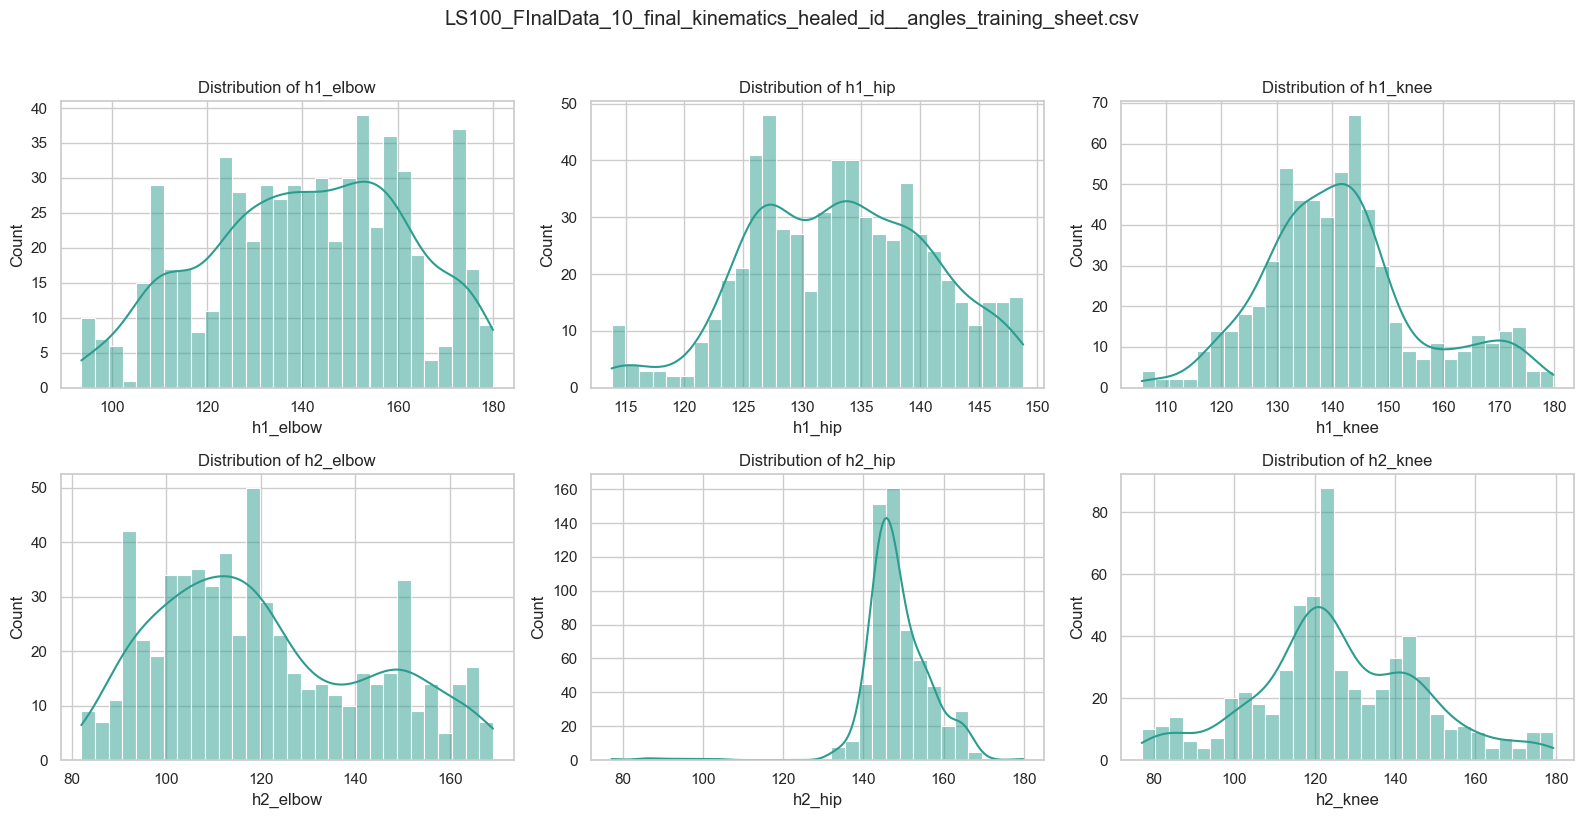


File: LS100_FInalData_11_final_kinematics_healed_id__angles_training_sheet.csv


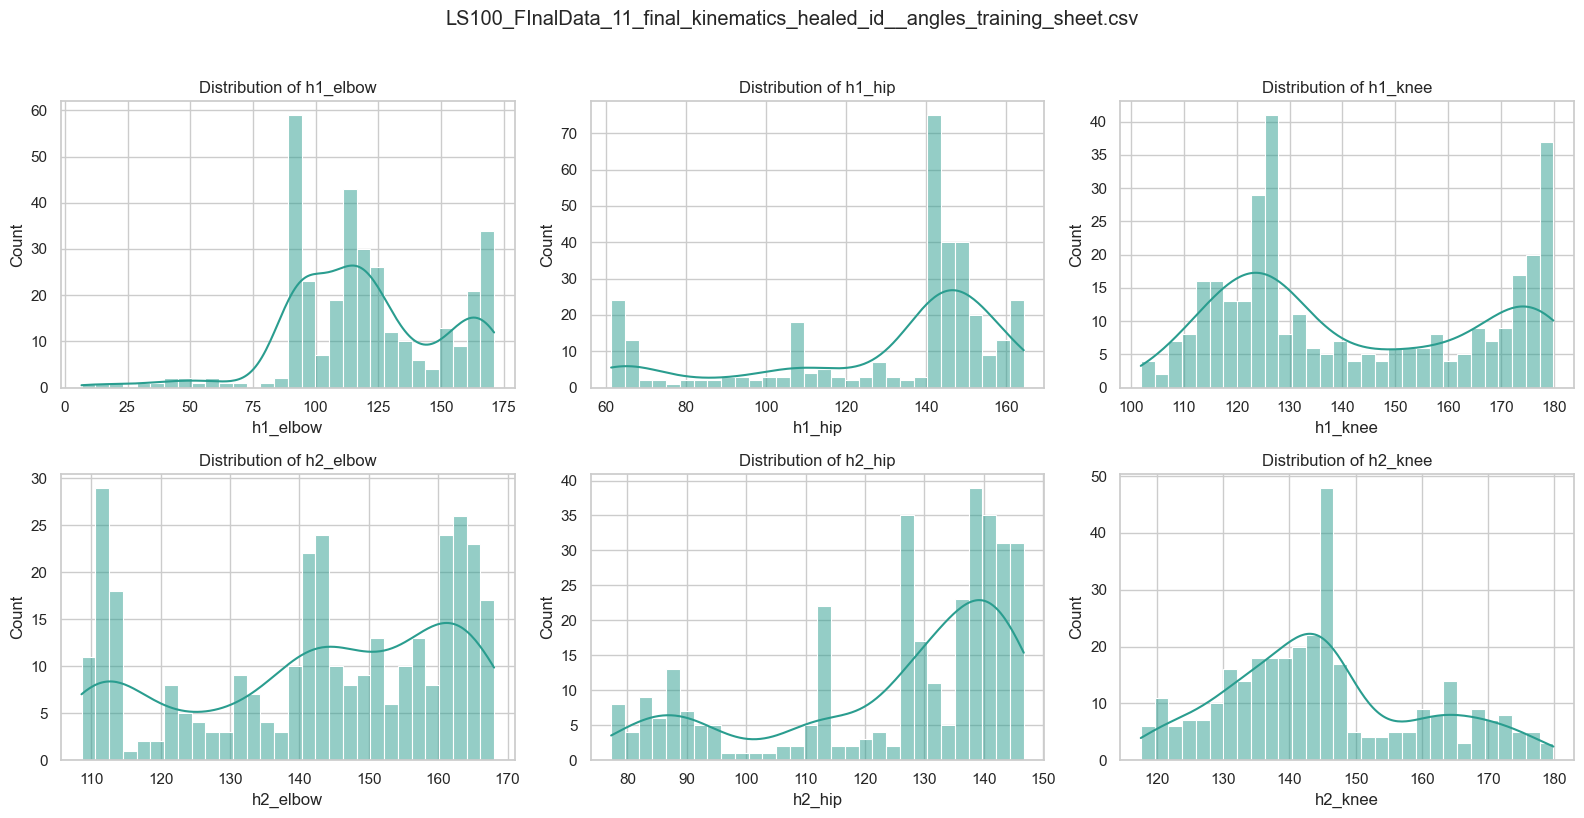

In [ ]:
# Example 1: single CSV file
# plot_angle_distributions_from_path("path/to/your/file.csv")

# Example 2: directory of CSV files
plot_angle_distributions_from_path(
    "/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/Henry/Henrys-Compile-Angles-Outputs/",
    max_files=2)

### 5. Understanding the statistics of each angle:

In [13]:
from scipy import stats


def build_richer_summary_table(path: str | Path) -> pd.DataFrame:
    """
    Build a richer summary table from all CSV files in a directory.
    
    Returns a DataFrame with one row per CSV file containing:
    - row_count: Total rows in the file
    - right_of_way: "h1_right_of_way" or "h2_right_of_way" (whichever contains 1)
    - For each angle column (h1_elbow, h1_hip, h1_knee, h2_elbow, h2_hip, h2_knee):
      - <col>__mean, __median, __mode, __std, __skewness, __kurtosis, __min, __max, __missing
    
    If a column is absent in a file, all its stats are None.
    """
    angle_cols = ["h1_elbow", "h1_hip", "h1_knee", "h2_elbow", "h2_hip", "h2_knee"]
    stat_names = ["mean", "median", "mode", "std", "skewness", "kurtosis", "min", "max", "missing"]
    
    target = Path(path).expanduser().resolve()
    
    if target.is_file() and target.suffix.lower() == ".csv":
        csv_files = [target]
    elif target.is_dir():
        csv_files = sorted(target.glob("*.csv"))
    else:
        raise ValueError("Provide a valid CSV file path or a directory containing CSV files.")
    
    if not csv_files:
        raise ValueError(f"No CSV files found at: {target}")
    
    results = []
    
    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        row_dict = {"file": csv_path.name}
        
        # Get row count
        row_dict["row_count"] = len(df)
        
        # Determine right_of_way
        right_of_way = None
        if "h1_right_of_way" in df.columns and df["h1_right_of_way"].eq(1).any():
            right_of_way = "h1_right_of_way"
        elif "h2_right_of_way" in df.columns and df["h2_right_of_way"].eq(1).any():
            right_of_way = "h2_right_of_way"
        
        row_dict["right_of_way"] = right_of_way
        
        # Calculate stats for each angle column
        for col in angle_cols:
            if col not in df.columns:
                # Column absent: set all stats to None
                for stat in stat_names:
                    row_dict[f"{col}__{stat}"] = None
            else:
                data = df[col].dropna()  # Skip missing values
                
                row_dict[f"{col}__missing"] = df[col].isna().sum()
                
                if len(data) == 0:
                    # All values are missing
                    for stat in stat_names[:-1]:  # Exclude "missing"
                        row_dict[f"{col}__{stat}"] = None
                else:
                    row_dict[f"{col}__mean"] = data.mean()
                    row_dict[f"{col}__median"] = data.median()
                    
                    # Mode - handle case where there might be no mode or multiple modes
                    try:
                        mode_val = stats.mode(data, keepdims=True).mode[0]
                    except:
                        mode_val = None
                    row_dict[f"{col}__mode"] = mode_val
                    
                    row_dict[f"{col}__std"] = data.std()
                    row_dict[f"{col}__skewness"] = stats.skew(data)
                    row_dict[f"{col}__kurtosis"] = stats.kurtosis(data)
                    row_dict[f"{col}__min"] = data.min()
                    row_dict[f"{col}__max"] = data.max()
        
        results.append(row_dict)
    
    return pd.DataFrame(results)

In [ ]:
df_data_summary = build_richer_summary_table("/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/Henry/Henrys-Compile-Angles-Outputs/")

df_data_summary

,file,row_count,right_of_way,h1_elbow__missing,h1_elbow__mean,h1_elbow__median,h1_elbow__mode,h1_elbow__std,h1_elbow__skewness,h1_elbow__kurtosis,...,h2_hip__max,h2_knee__missing,h2_knee__mean,h2_knee__median,h2_knee__mode,h2_knee__std,h2_knee__skewness,h2_knee__kurtosis,h2_knee__min,h2_knee__max
0,LS100_FInalData_10_final_kinematics_healed_id_...,618,h2_right_of_way,0,140.801715,141.709192,93.637943,21.003747,-0.177714,-0.794377,...,179.856592,0,125.604330,123.056977,76.904565,21.322138,0.111628,-0.004064,76.904565,179.440790
1,LS100_FInalData_11_final_kinematics_healed_id_...,333,h1_right_of_way,0,119.710855,116.060552,6.649465,30.685137,-0.273815,0.567607,...,146.716128,1,145.002022,143.959479,117.540302,14.717420,0.427649,-0.463741,117.540302,179.881549
2,LS100_FInalData_12_final_kinematics_healed_id_...,369,h1_right_of_way,0,134.263209,141.361281,4.453203,27.181314,-0.993727,2.086806,...,176.155464,0,132.401329,132.382557,109.019769,14.823920,0.376898,-0.720412,109.019769,167.757074
3,LS100_FInalData_13_final_kinematics_healed_id_...,350,h1_right_of_way,69,136.498587,138.305600,18.239225,25.547231,-0.876000,1.521301,...,179.693328,0,134.397348,129.639445,93.660156,20.937487,0.033463,-0.685888,93.660156,177.394114
4,LS100_FInalData_14_final_kinematics_healed_id_...,334,h2_right_of_way,1,142.205291,151.330336,91.239057,18.392685,-0.504466,-1.211166,...,177.025333,0,144.941899,141.577117,92.351109,23.226294,-0.090737,-0.982049,92.351109,179.804467
5,LS100_FInalData_15_final_kinematics_healed_id_...,409,h2_right_of_way,0,143.226060,147.931664,110.821656,15.549718,-0.205586,-0.908331,...,176.596164,52,140.871011,135.435371,110.939504,20.235552,0.435857,-1.145170,110.939504,179.607271
6,LS100_FInalData_16_final_kinematics_healed_id_...,478,h2_right_of_way,0,141.443651,146.044080,0.834967,30.318225,-1.761632,4.337764,...,140.000147,0,146.320679,147.815335,116.963904,13.117974,-0.186535,-0.052000,116.963904,177.283081
7,LS100_FInalData_17_final_kinematics_healed_id_...,1170,h2_right_of_way,295,144.310170,146.503737,0.207954,25.204919,-1.366727,4.626697,...,171.044731,1,138.221398,137.659560,70.008804,25.629860,-0.295289,-0.474382,70.008804,179.977151
8,LS100_FInalData_18_final_kinematics_healed_id_...,448,h1_right_of_way,1,133.646258,126.869712,81.722814,28.894384,0.022310,-1.450555,...,172.003860,1,150.504057,151.645559,93.104985,19.376852,-0.638756,0.042137,93.104985,179.846968
9,LS100_FInalData_19_final_kinematics_healed_id_...,359,h1_right_of_way,0,138.601651,143.916370,88.920318,21.401779,-0.334562,-1.170685,...,177.447145,1,138.784371,141.167255,79.843089,18.095595,-0.622252,1.115992,79.843089,179.999788
